# Graph DB와 Neo4j 시작하기

## Graph DB란?

**Graph DB(Graph Database, 그래프 데이터베이스)** 는 데이터의 대상뿐 아니라 대상 사이의 **관계**도 직접 저장하고 조회하는 데이터베이스이다. 대상은 노드로, 연결은 방향과 이름을 가진 관계로 표현한다.

관계형 DB가 행과 외래 키를 `JOIN`해 연결을 계산한다면, Graph DB는 연결 자체를 저장하고 관계를 따라 이동한다. 따라서 여러 단계를 거쳐야 하는 질문을 자연스럽게 표현할 수 있다.

```text
(민지:Person)-[:WORKS_AT]->(SKN:Organization)-[:OFFERS]->(RAG:Course)
```

위 구조에서는 `민지 → SKN → RAG` 경로를 따라가며 "민지가 소속된 기관에서 제공하는 강좌는 무엇인가?"를 조회한다. 이처럼 연결 경로가 답의 핵심인 지식 그래프, 추천, 조직 관계, 이상 거래 탐지와 Graph RAG에 Graph DB를 사용한다.

## Neo4j란?

**Neo4j**는 Graph DB를 실제로 저장하고 조회하는 Graph DBMS(Database Management System)이다.

데이터를 Property Graph로 표현하고, `Cypher(사이퍼)`라는 질의 언어로 노드와 관계 패턴을 다룬다.

- **Neo4j 인스턴스**: 노드·관계·속성을 저장하고 Cypher를 실행하는 서버이다.
- **AuraDB**: Neo4j 인스턴스를 클라우드에서 운영해 주는 관리형 서비스이다.
- **Neo4j Python Driver**: Python 코드가 실행 중인 Neo4j 인스턴스에 접속하도록 연결하는 클라이언트이다. 서버를 설치하거나 생성하지 않는다.

이 실습은 **AuraDB에 그래프 저장 → Python Driver로 접속 → Cypher로 관계 조회** 순서로 진행한다.

---
## 속성 그래프

Neo4j는 **Property Graph(속성 그래프)** 모델을 사용한다. 속성 그래프는 노드와 관계에 이름이 있는 속성을 함께 저장하므로, 대상의 정보와 연결의 의미를 한 구조에서 표현할 수 있다.

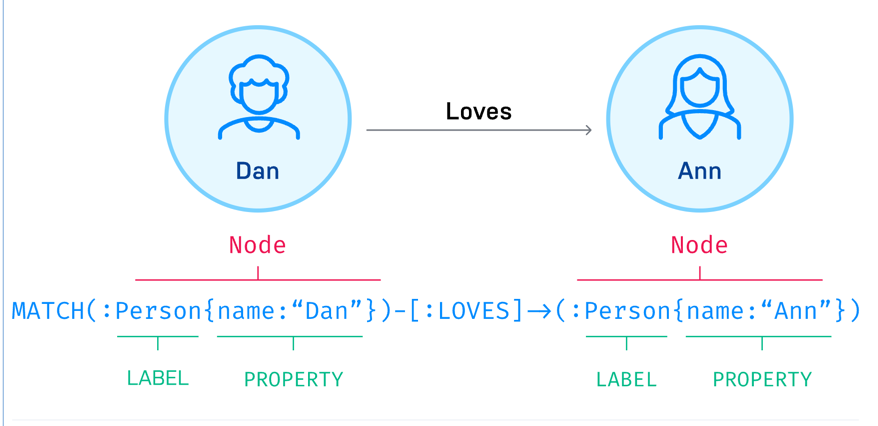

그림은 위쪽 그래프와 아래쪽 Cypher를 같은 위치끼리 연결해 읽는다.

1. **Node(노드)**: `Dan`, `Ann`처럼 독립적으로 식별하는 대상이다.
2. **Label(라벨)**: `Person`처럼 노드의 종류를 나타낸다.
3. **Property(속성)**: `name: 'Dan'`처럼 노드나 관계가 가진 `key: value` 정보이다.
4. **Relationship(관계)**: `LOVES`처럼 두 노드가 어떻게 연결되는지 나타내며 화살표가 방향을 표시한다.

이어지는 코드에서는 같은 자리에 `(:Person {name: '민지'})-[:WORKS_AT]->(:Organization {name: 'SKN'})`을 저장한다.

`Cypher(사이퍼)`는 이러한 노드·관계 패턴을 괄호 `()`와 화살표 `-[]->`로 표현하는 Neo4j 질의 언어이다.

출처: [Neo4j 공식 Getting Started - What is a graph database?](https://neo4j.com/docs/getting-started/graph-database/)의 `sample-cypher.svg` (© Neo4j).

## Cypher 구문 작성하고 읽기

Cypher는 원하는 그래프 모양을 **노드 → 관계 → 노드** 순서로 그리듯 작성하는 질의 언어이다. 먼저 찾을 경로를 작성하고, 필요한 조건과 반환값을 뒤에 붙인다.

### 1. 그래프 패턴 읽기

```cypher
(person:Person {name: '민지'})-[:WORKS_AT]->(organization:Organization)
```

왼쪽에서 오른쪽으로 다음과 같이 읽는다.

- `(person:Person {name: '민지'})`: `person`이라는 변수로 참조할 `Person` 노드이며, `name` 속성값은 `민지`이다.
- `[:WORKS_AT]`: 관계 종류는 `WORKS_AT`이다.
- `->`: 관계가 사람에서 기관 방향으로 향한다.
- `(organization:Organization)`: 도착점은 `organization` 변수로 참조할 `Organization` 노드이다.

즉, 전체 패턴은 **민지가 어떤 기관에서 근무한다**는 연결을 나타낸다.

### 2. 조회 구문 작성 순서

```cypher
MATCH (person:Person)-[:WORKS_AT]->(organization:Organization)
WHERE person.name = '민지'
RETURN organization.name AS organization
ORDER BY organization
```

- `MATCH`: 저장된 그래프에서 일치하는 노드·관계 패턴을 찾는다.
- `WHERE`: 찾은 결과에 조건을 적용한다.
- `RETURN`: 화면이나 Python으로 돌려줄 값을 선택한다.
- `AS`: 반환되는 열에 읽기 쉬운 이름을 붙인다.
- `ORDER BY`: 반환 결과의 정렬 순서를 지정한다.

따라서 위 구문은 **Person에서 WORKS_AT 관계를 따라 Organization을 찾고 → 이름이 민지인 Person만 남기고 → 기관 이름을 반환하고 → 기관 이름순으로 정렬한다**고 해석한다.

### 3. 적재 구문에서 사용하는 명령

- `UNWIND $rows AS row`: Python에서 전달한 `$rows` 목록을 하나씩 꺼내 `row`로 처리한다.
- `MERGE`: 같은 노드나 관계가 있으면 재사용하고, 없으면 생성한다.
- `$rows`: Python이 Cypher에 전달하는 매개변수이며 실제 값과 질의 문법을 분리한다.

라벨·관계 종류·속성 이름과 관계 방향이 저장된 그래프와 다르면 결과가 비어 있을 수 있다. 이어지는 적재 셀에서는 `UNWIND`와 `MERGE`를, 조회 셀에서는 `MATCH`, `RETURN`, `ORDER BY`를 실제로 사용한다.

## Graph DB와 Vector DB의 역할

Graph DB와 Vector DB는 모두 검색에 사용할 수 있지만, 저장하는 정보와 질문을 해결하는 방식이 다르다.

| 비교 기준 | Vector DB | Graph DB |
|---|---|---|
| 저장하는 핵심 | 문서와 임베딩 벡터 | 노드·관계·속성 |
| 검색 기준 | 의미적 유사도 | 명시된 관계와 경로 |
| 잘 맞는 질문 | "RAG와 비슷한 자료는?" | "민지가 속한 기관의 강좌는?" |
| 대표 결과 | 유사한 문서 목록 | 연결된 노드와 경로 |

둘 중 하나만 선택해야 하는 것은 아니다. Hybrid RAG에서는 벡터 검색으로 관련 후보를 찾고 Graph DB의 관계를 따라 주변 근거를 확장한다.

## AuraDB Free 가입과 인스턴스 생성

### 1. Neo4j 계정 만들기

[Neo4j Aura Console](https://console.neo4j.io/)에 접속해 계정을 만들고 로그인한다. Console은 인스턴스를 만들고 상태를 확인하는 관리 화면이다.

### 2. AuraDB Free 인스턴스 만들기

Console에서 `Create instance`를 선택하고 제품은 `AuraDB`, tier는 `Free`로 설정한다. 인스턴스 이름을 정해 생성을 완료한 뒤 상태가 `Running`인지 확인한다.

**인스턴스(instance)** 는 실제 그래프 데이터를 저장하고 Cypher를 실행하는 하나의 Neo4j 서버이다. AuraDB Free 인스턴스가 일시 중지된 경우에는 Console에서 `Resume`한 뒤 연결한다.

### 3. 접속 정보 저장하기

**접속 정보(credentials)**는 Driver가 서버를 찾고 인증하는 데 필요한 값의 묶음이다. 생성 직후 제공되는 credentials 파일을 다운로드하거나 다음 네 값을 안전하게 보관한다.

| 항목 | 용도 | 주의할 점 |
|---|---|---|
| Connection URI | Driver가 접속할 서버 주소 | 보통 `neo4j+s://...databases.neo4j.io` 형식이다. |
| User name | 데이터베이스 로그인 사용자명 | Aura Console 로그인 이메일과 다를 수 있다. |
| Password | 데이터베이스 접속 비밀번호 | 생성 화면을 닫기 전에 반드시 저장한다. |
| Database name | Cypher를 실행할 데이터베이스 | credentials에 표시된 값을 사용한다. |

credentials 파일과 비밀번호는 Git에 올리거나 화면 공유에 노출하지 않는다. 공식 절차는 [AuraDB 인스턴스 생성](https://neo4j.com/docs/aura/getting-started/create-instance/)과 [AuraDB 연결](https://neo4j.com/docs/aura/getting-started/connect-instance/)에서 확인할 수 있다.

## 설치와 실행 준비

앞에서 만든 AuraDB 인스턴스에 Python으로 접속할 패키지를 설치한다. **Driver(드라이버)**는 Python 코드와 Neo4j 서버 사이의 연결을 관리하는 클라이언트이다.

`%pip`는 현재 Jupyter 커널 환경에 패키지를 설치하고, `-U`는 이미 설치된 패키지를 호환 가능한 최신 버전으로 갱신한다. `neo4j`는 공식 Python Driver를, `python-dotenv`는 `.env` 설정 로더를 제공한다. 이 명령은 Neo4j 서버나 AuraDB 인스턴스를 만들지 않는다.

공식 문서는 [Neo4j Python Driver](https://neo4j.com/docs/python-manual/current/)와 [Cypher Manual](https://neo4j.com/docs/cypher-manual/current/)에서 확인할 수 있다. 로컬 서버로 실습하려면 AuraDB 대신 [Neo4j Desktop](https://neo4j.com/docs/desktop/current/installation/)을 별도로 설치하고 DBMS를 실행해야 한다.

In [1]:
%pip install -U neo4j python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## AuraDB 접속 정보를 .env에 등록하기

AuraDB 생성 화면이나 credentials 파일에서 확인한 접속 정보를 `08_llm/.env`에 등록한다. 값의 따옴표와 꺾쇠괄호는 작성하지 않는다.

```dotenv
NEO4J_URI=neo4j+s://your-instance.databases.neo4j.io
NEO4J_USERNAME=your-database-username
NEO4J_PASSWORD=your-database-password
NEO4J_DATABASE=your-database-name
```

| 환경 변수 | credentials에서 가져올 값 |
|---|---|
| `NEO4J_URI` | **Connection URI**를 그대로 사용하며 Aura Console 웹 주소를 넣지 않는다. |
| `NEO4J_USERNAME` | **User name**을 사용하며 Neo4j 사이트 로그인 이메일과 구분한다. |
| `NEO4J_PASSWORD` | 인스턴스 생성 시 발급된 데이터베이스 비밀번호를 사용한다. |
| `NEO4J_DATABASE` | credentials의 **Database name**을 사용한다. |

`.env`는 코드와 분리해 비밀값을 보관하는 파일이다. Git에 커밋하거나 학생에게 공유하지 않는다. 다음 셀은 `.env` 위치와 네 환경 변수의 존재만 확인하며 실제 값은 출력하지 않는다.

In [1]:
import os

from dotenv import find_dotenv, load_dotenv
from neo4j import GraphDatabase

dotenv_path = find_dotenv(usecwd=True)

if not dotenv_path:
    raise FileNotFoundError("08_llm 프로젝트 폴더에 .env 파일을 생성한다.")

load_dotenv(dotenv_path=dotenv_path, override=False)

neo4j_uri = os.environ["NEO4J_URI"]
neo4j_username = os.environ["NEO4J_USERNAME"]
neo4j_password = os.environ["NEO4J_PASSWORD"]
neo4j_database = os.environ["NEO4J_DATABASE"]


## Neo4j 드라이버로 연결하기

앞에서 읽은 접속 설정으로 재사용 가능한 Neo4j `driver`를 만든다. Driver 생성은 연결 방법을 준비하는 단계이며, `verify_connectivity()`를 호출할 때 실제 서버 연결과 인증을 확인한다.

> **연결 흐름:** Python 코드 → `GraphDatabase.driver()` → AuraDB → `verify_connectivity()` 성공 여부

**URI(Uniform Resource Identifier)** 는 접속할 서버의 위치와 연결 방식을 함께 나타내는 주소이다. 로컬 서버는 보통 `neo4j://localhost:7687`, AuraDB는 발급된 `neo4j+s://...` 주소를 사용한다. `GraphDatabase.driver(uri, auth=...)`는 URI와 `(사용자명, 비밀번호)`를 받아 Driver를 반환한다.

Driver는 연결 설정과 연결 풀을 관리한다. 저수준 API에서는 **Session**이 작업 범위를 열고 **Transaction**이 여러 Cypher를 하나의 성공·실패 단위로 묶지만, 이 교안의 `driver.execute_query()`는 두 관리를 내부에서 처리한다.

### 연결 오류를 확인하는 순서

- `URI scheme b'' is not supported`: `NEO4J_URI`가 비어 있거나 `.env`를 찾지 못한 경우이다. 바로 앞 환경 변수 셀부터 다시 확인한다.
- `AuthError`: credentials의 User name과 Password를 다시 확인한다. Aura Console 로그인 계정과 DB 계정을 혼동하지 않는다.
- `ServiceUnavailable` 또는 timeout: AuraDB 상태가 `Running`인지, Connection URI를 그대로 복사했는지, 네트워크가 연결을 차단하는지 확인한다.
- database 관련 오류: credentials의 Database name과 `NEO4J_DATABASE`가 같은지 확인한다.

In [2]:
# 1. Neo4j 연결 드라이버 생성
driver = GraphDatabase.driver(
    uri=neo4j_uri,
    auth=(neo4j_username, neo4j_password)
)

# 2. 드라이버가 잘 생성 되었는지 확인
driver.verify_connectivity()

# 에러가 발생하지 않으면 정상 연결

## 수업용 그래프 적재하기

Python 딕셔너리 목록을 Cypher에 전달해 Person·Organization·Course 노드와 세 종류의 관계를 적재한다. 입력 한 행은 사람·기관·강좌 한 묶음이며, `UNWIND`가 목록을 행 단위로 펼친다.

| 구문 | 반복 실행 시 동작 | 현재 실습의 선택 |
|---|---|---|
| `CREATE` | 실행할 때마다 새 요소를 만든다. | 중복 데이터가 생길 수 있어 사용하지 않는다. |
| `MERGE` | 같은 패턴이 있으면 재사용하고 없으면 만든다. | 노트북을 다시 실행해도 중복을 줄이기 위해 사용한다. |

Cypher는 다음 순서로 읽는다.

1. `UNWIND $rows AS row`가 Python 목록을 Cypher의 여러 행으로 바꾼다.
2. `(person:Person {name: row.person})`가 라벨 `Person`과 `name` 속성을 가진 노드를 찾거나 만든다.
3. `(person)-[:WORKS_AT]->(organization)`가 두 노드 사이에 방향이 있는 관계를 연결한다.

`$rows`는 Python이 전달하는 **Cypher 매개변수**이다. 동적 값을 질의 문자열에 직접 붙이지 않고 매개변수로 전달하면 값과 Cypher 문법을 분리하고 injection 위험을 줄일 수 있다.

In [6]:
# 1. Cypher에 전달할 입력 목록
graph_rows = [
    {'person': '민지', 'organization':'SKN', 'course':'RAG'},
    {'person': '현우', 'organization':'SKN', 'course':'LangGraph'},
]

# 2. 1번에 작성한 각 입력 행을
#    노드 3개, 관계 3개로 바꾸는 Cypher 문자열 작성
write_query = '''
// 1. 파이썬에서 전달한 $rows 목록을 한 행씩 꺼내어 row라고 부름
UNWIND $rows AS row

// 2. row.person 값을 name 속성으로 갖는 Person 노드를 찾고
//    없으면 노드 생성하기
//    -> 현재 cypher 구문 내에서 person이라고 부르도록 변수 설정
MERGE (person:Person {name: row.person})

// 3. 같은 방법을 조직, 코스 준비
MERGE (organization:Organization {name: row.organization})
MERGE (course:Course {title: row.course})

// 4. person --> organization으로 향하는 근무 관계를 찾거나 생성
MERGE (person) -[:WORKS_AT]-> (organization)

// 5. organization -> course으로 향하는 제공(OFFERS) 관계
MERGE (organization) -[:OFFERS]-> (course)

// 6. person -> course로 향하는 담당 선생(TEACHERS) 관계
MERGE (person) -[:TEACHERS]-> (course)
'''

# 3. 완성된 Cypher 구문을 실행
_, write_summary, _ = driver.execute_query(
    write_query,
    rows=graph_rows,
    database_=neo4j_database
)

print("생성된 노드 수: ",
      write_summary.counters.nodes_created)

print("생성된 관계 수: ",
      write_summary.counters.relationships_created)

생성된 노드 수:  5
생성된 관계 수:  6


## 관계 경로 조회하기

질문 “민지가 소속된 기관이 제공하는 강좌는 무엇인가?”를 두 관계를 거치는 Cypher 패턴으로 바꾼다. **hop**은 관계를 이동한 횟수이므로 다음 패턴은 2-hop 조회이다.

```text
(Person)-[:WORKS_AT]->(Organization)-[:OFFERS]->(Course)
   출발점             1-hop                    2-hop
```

`MATCH`는 저장된 패턴을 찾고, `RETURN ... AS ...`는 결과에 포함할 값과 열 이름을 정한다. `ORDER BY course`는 강좌 이름을 오름차순으로 정렬한다.

`execute_query()`는 결과를 모두 모은 `EagerResult`를 반환하며 세 값으로 나눠 받는다.

| 반환값 | 의미 | 다음 사용처 |
|---|---|---|
| `records` | 각 조회 행을 담은 `Record` 목록 | `record.data()`로 Python 딕셔너리로 바꾼다. |
| `summary` | 실행 시간과 질의 유형 같은 서버 정보 | 성능과 읽기·쓰기 유형을 확인한다. |
| `keys` | 결과 열 이름 목록 | 반환 구조를 확인한다. |

In [8]:
# 1. 조회 쿼리 작성
read_query = '''
// 1) Person 노드 중에서 name 속성 값이 $person_name인 노드를 찾고
//    이어지는 Organization, Course 경로 찾기
MATCH (p:Person {name: $person_name})
    -[:WORKS_AT]-> (org:Organization)
    -[:OFFERS]-> (c:Course)

// 2) 전체 노드 대신, 화면에 보여줄 속성만 선택하고, 컬럼명 붙이기
RETURN p.name AS person,
       org.name AS organization,
       c.title AS course
'''

# 2. 조회 실행 후 결과 반환 받기
# records: 조회된 경로마다 한 개의 Record가 들어있는 목록
# read_summary: 실행 정보 요약
# keys: RETURN에서 지정한 컬럼명(별칭) 목록
records, read_summary, keys = driver.execute_query(
    read_query,
    person_name = '민지', # $person_name에 들어갈 값
    database_=neo4j_database
)

print("결과 열:", keys)
print("결과 행 수:", len(records))

for record in records:
    print(record.data()) # 한 결과 행을 dict로 변경후 출력

print("결과 준비 시간(ms):",
      read_summary.result_available_after)

결과 열: ['person', 'organization', 'course']
결과 행 수: 2
{'person': '민지', 'organization': 'SKN', 'course': 'RAG'}
{'person': '민지', 'organization': 'SKN', 'course': 'LangGraph'}
결과 준비 시간(ms): 1


## 관계 방향 확인하기

관계의 화살표는 출발 노드와 도착 노드를 구분한다. 저장된 `TEACHES`의 의미는 **Person이 Course를 가르친다**이므로 그래프에는 `Person → Course` 방향으로 저장한다.

조회 질문은 “RAG 강좌를 가르치는 사람은 누구인가?”이므로 Course에서 출발한다고 생각할 수 있지만, Cypher에는 저장된 관계 방향인 `(Person)-[:TEACHES]->(Course)`를 그대로 적고 Course의 `title`을 조건으로 제한한다. `collect(person.name)`은 일치하는 여러 Person 이름을 하나의 목록으로 모은다.

관계 방향을 잘못 작성하면 노드가 존재해도 결과가 비어 있을 수 있다. 결과가 없으면 속성값뿐 아니라 라벨·관계 유형·방향을 함께 확인한다.

In [18]:
# 1. 코스 제목 지정
course_title = 'RAG'

# 2. course_query: Person → Course 방향으로 저장된 TEACHES 관계를 찾는 Cypher
course_query = '''
// 1. Person에서 TEACHES 화살표를 따라 title이 $course_title인 Course 찾기
MATCH (person:Person)
    -[:TEACHERS]-> (course:Course {title: $course_title})

// 2. RETURN 구문 작성
RETURN course.title AS course, collect(person.name) AS instructors
'''

# 3. 실행 후 결과 반환 받기
course_records, course_summary, course_keys = driver.execute_query(
    course_query,
    course_title=course_title,
    database_=neo4j_database
)

# 4. course_keys와 course_records로 결과 열과 조회 행 수 확인
print('결과 열:', course_keys)
print('결과 행 수:', len(course_records))
# data(): Record를 {'course': 'RAG', 'instructors': ['민지']} 구조의 딕셔너리로 변환한다.
for record in course_records:
    print(record.data())

# query_type: 서버가 분류한 질의 유형이며 읽기 전용 질의는 'r'이다.
print('질의 유형:', course_summary.query_type)

# 관계 방향과 코스 제목이 일치하면
# Person --> Course 관계여도 역으로 확인할 수 있다.

DriverError: Driver closed

## 연결 정리와 다음 단계

`driver.close()`는 Driver가 관리하던 네트워크 연결 자원을 정리한다. Driver 객체와 서버에 저장된 그래프 데이터는 별개이므로 연결을 닫아도 노드와 관계는 유지된다.

다음 Graph RAG(Graph Retrieval-Augmented Generation) 단원에서는 **자연어 질문 → Cypher 생성 → Neo4j 조회 → 조회 결과를 근거로 LLM 답변 생성** 흐름을 구성한다.

In [17]:
driver.close()